In [1]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from collections import deque 
from codigo_PD import programacion_dinamica_sofia

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [2]:
x = np.linspace(100, 10000, 20).astype(int)

def get_random_cant_monedas(s):
    # devuelve un array aleatorio de numeros mayores a 0 
    return [random.randint(1, 1000) for _ in range(s)]


results = time_algorithm(programacion_dinamica_sofia, x, lambda s: [get_random_cant_monedas(s)])

print(results)

ValueError: max_workers must be greater than 0

Text(0, 0.5, 'Tiempo de ejecución (s)')

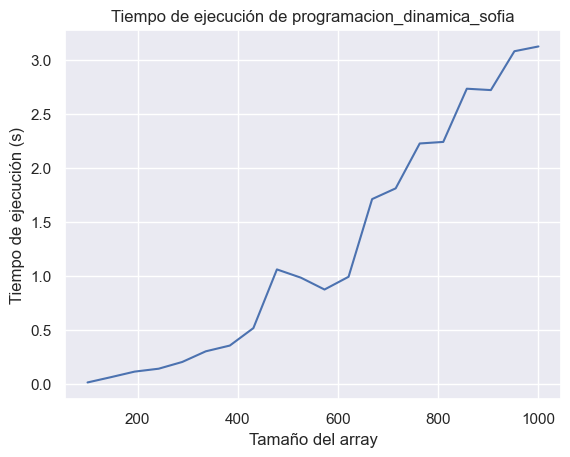

In [ ]:
ax: plt.Axes
fig, ax = plt.subplots()
ax.plot(x, [results[i] for i in x], label="Medición")
ax.set_title('Tiempo de ejecución de programacion_dinamica_sofia')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')


In [ ]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f = lambda x, c1, c2: c1 * x * np.log(x) + c2 

c, pcov = sp.optimize.curve_fit(f, x, [results[n] for n in x])

print(f"c_1 = {c[0]}, c_2 = {c[1]}")
r = np.sum((c[0] * x * np.log(x) + c[1] - [results[n] for n in x])**2)
print(f"Error cuadrático total: {r}")

c_1 = 0.0005294502855566971, c_2 = -0.6122537819224473
Error cuadrático total: 1.0756768600136934


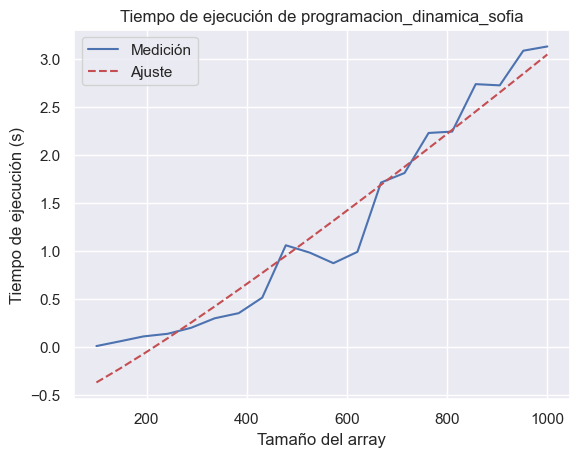

In [ ]:
ax.plot(x, [c[0] * n * np.log(n) + c[1] for n in x], 'r--', label="Ajuste")
ax.legend()
fig

Text(0, 0.5, 'Error absoluto (s)')

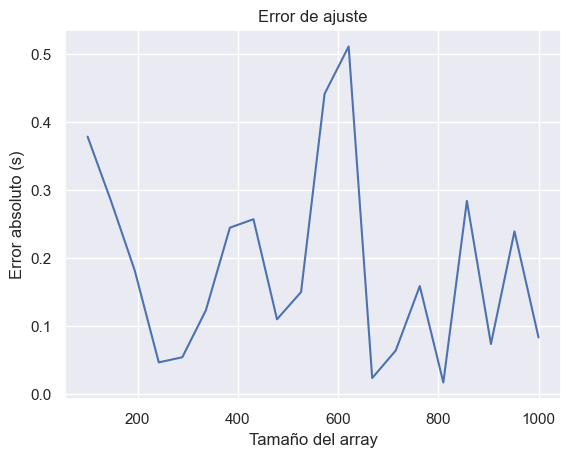

In [ ]:
ax: plt.Axes
fig, ax = plt.subplots()
errors = [np.abs(c[0] * n * np.log(n) + c[1] - results[n]) for n in x]
ax.plot(x, errors)
ax.set_title('Error de ajuste')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Error absoluto (s)')